# Practice Using Breast Cancer Data

The load_breast_cancer command provides breast cancer diagnosis data. It uses features measured from tumor images to determine whether a tumor is benign or malignant.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

In [3]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["class"] = cancer.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


## Investigate and Visualize

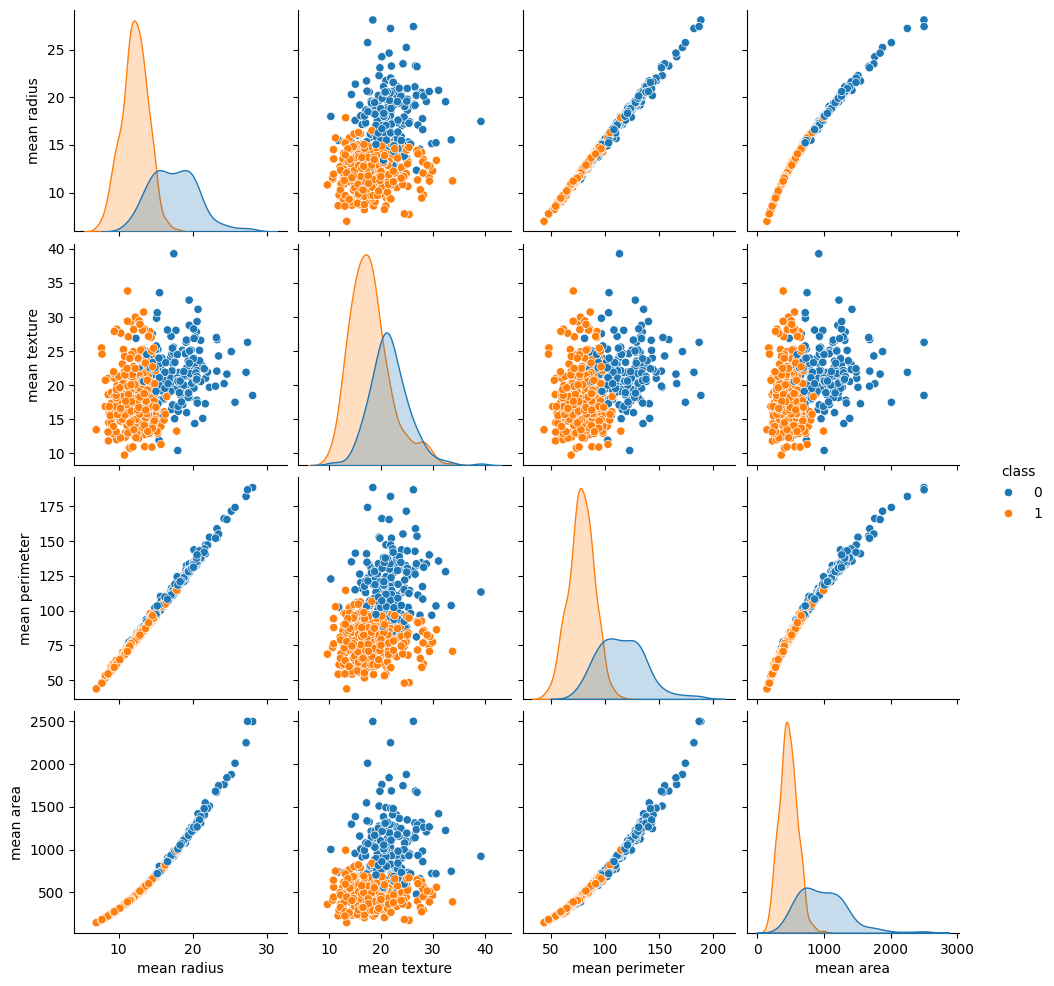

In [11]:
sns.pairplot(
    vars=["mean radius", "mean texture", "mean perimeter", "mean area"],
    hue="class",
    data=df,
)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver="liblinear", C=1)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [15]:
print("Accuracy on the training subset: {:.3f}".format(log_reg.score(X_train, y_train)))
print("Accuracy on the test subset: {:.3f}".format(log_reg.score(X_test, y_test)))

Accuracy on the training subset: 0.953
Accuracy on the test subset: 0.958


### Regularization:
Prevent overfitting.

L1 - Keeps only important variables.

L2 - Default. Penalizes weights of less important variables, pushing them closer to zero.

The regularization strength parameter C is important.

Decreasing C increases the strength of regularization.

Lower C ⇒ stronger regularization; weights are pushed closer to zero, which may cause underfitting.

Higher C ⇒ weaker regularization; the model tries to fit all data points as much as possible, which may cause overfitting.

Practice: Regularization
- Change C to 999 and evaluate the model.
- Change C to 0.01 and evaluate the mode

In [16]:
log_reg999 = LogisticRegression(solver="liblinear", C=999)
log_reg999.fit(X_train, y_train)
print(
    "Accuracy on the training subset: {:.3f}".format(log_reg999.score(X_train, y_train))
)
print("Accuracy on the test subset: {:.3f}".format(log_reg999.score(X_test, y_test)))

Accuracy on the training subset: 0.977
Accuracy on the test subset: 0.965


In [17]:
log_reg001 = LogisticRegression(solver="liblinear", C=0.01)
log_reg001.fit(X_train, y_train)
print(
    "Accuracy on the training subset: {:.3f}".format(log_reg001.score(X_train, y_train))
)
print("Accuracy on the test subset: {:.3f}".format(log_reg001.score(X_test, y_test)))

Accuracy on the training subset: 0.934
Accuracy on the test subset: 0.930


In [18]:
prob = log_reg999.predict_proba(X_test[:10, :])
prob.round(2)

array([[0.01, 0.99],
       [1.  , 0.  ],
       [0.15, 0.85],
       [0.08, 0.92],
       [0.27, 0.73],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ]])

In [19]:
prob = log_reg001.predict_proba(X_test[:10, :])
prob.round(2)

array([[0.06, 0.94],
       [1.  , 0.  ],
       [0.13, 0.87],
       [0.22, 0.78],
       [0.17, 0.83],
       [1.  , 0.  ],
       [0.47, 0.53],
       [1.  , 0.  ],
       [0.95, 0.05],
       [0.03, 0.97]])

When C is large (weaker regularization), the model tries to fit the data more closely and tends to produce more extreme probability values.

When C is small (stronger regularization), the model is more conservative and produces smoother, less extreme probability distributions.

# Decision Boundary Plotting

In [25]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'class'],
      dtype='object')

In [38]:
X = df[["mean perimeter", "mean area"]]
y = df["class"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [42]:
log_reg999 = LogisticRegression(solver="liblinear", C=999)
log_reg999.fit(X_train, y_train)
print(
    "Accuracy on the training subset: {:.3f}".format(
        log_reg999.score(X_train, y_train))
)
print("Accuracy on the test subset: {:.3f}".format(
    log_reg999.score(X_test, y_test)))

Accuracy on the training subset: 0.869
Accuracy on the test subset: 0.930


In [43]:
from matplotlib.colors import ListedColormap
import numpy as np

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # Set up marker shapes and color map
    markers = ("s", "x", "o", "^", "v")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Create a mesh grid over the feature space
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Predict the class label for each point on the grid
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    # Draw the decision boundary
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot the class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=cl,
        )

In [44]:
# plot_decision_regions(
#     X_combined_scaled, y_combined, classifier=model2, test_idx=range(105, 150)
# )
plot_decision_regions(X_train, y_train, log_reg)

InvalidIndexError: (slice(None, None, None), 0)